# K-Nearest Neighbors for Regression Models.

### Introducción

* Imagenemos que tenemos los siguientes datos que van en releación del precio de un carro en base a los kilometros recorridos.
* Parecido a lo que hariamos en el KNN-Classifier, aca también tratamos de buscar los vecinos K de nuestro Km para tratar de saber su precio.
* En el ejemplo podemos ver como probablemente los autos con menor kilometraje sean de lujo y además si precio.

![KNN-Regressor.png](KNN-Regressor.png)

### Datos de clientes bancarios: crédito

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

# Cargar datos 
carros = pd.read_csv("carros.csv")
carros.head(10)

,kms,precio
0,6048,1385956
1,11825,1297582
2,20000,1000000
3,21048,1284844
4,21549,685300
5,21613,1342000
6,24184,1207484
7,25000,1005000
8,27027,655402
9,27863,814000


### Escalamiento de datos.

* En este apartado podremos ver un como se distribuyen los datos.
* Recordemos que para este modelo es super importanticimo el que los datos esten escalados.
* Podemos ver  que siguen el mismo flujo.
* `alpha`: recordemos que nos ayuda con la transparencia de los datos.

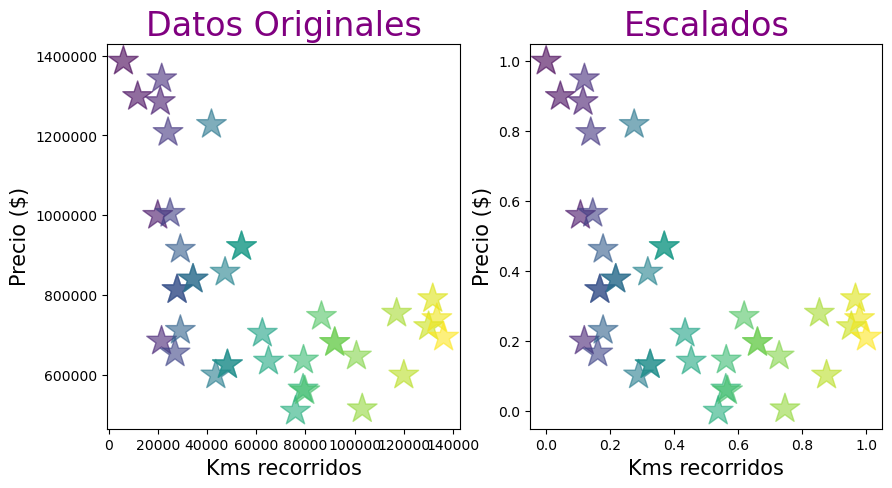

In [7]:
#### Graficar datos crudos: kms vs precio.
fig = plt.figure(figsize=(10, 5))

### Establecemos que habrá 2 grafos en el lienzo, estees el primero.
ax = fig.add_subplot(1, 2, 1)

ax.scatter(x=carros["kms"], y=carros["precio"], marker="*",
           s=500, c=range(carros["kms"].size), alpha=0.6)

ax.set_title("Datos Originales", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")


### Escalamiento de los datos 
### Empezamos por instanciar los 2 scalers para los 2 datos.
escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()

### Hacemos que escalen, pero pasandole un array de numpy y no la serie.
kms = escala_kms.fit_transform(carros["kms"].values.reshape(-1, 1))
precio = escala_precio.fit_transform(carros["precio"].values.reshape(-1, 1))


### Graficar datos escalados: kms vs precio
ax = fig.add_subplot(1, 2, 2)
ax.scatter(x=kms, y=precio, marker="*", 
           s=500, c=range(kms.size), alpha=0.6)

ax.set_title("Escalados", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")

plt.show()

### Segmentación de la información disponible

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    kms,
    precio,
    test_size= 0.20,
    random_state=42
)

### Ajuste Hiperparametros

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Definimos la rejilla de hiperparámetros que queremos explorar
parametros = {
    "n_neighbors": [2, 3, 5, 7, 10],      # número de vecinos
    "weights": ["uniform", "distance"],   # cómo ponderar los vecinos
    "metric": ["euclidean", "manhattan"]  # tipo de distancia
}

# Creamos el modelo base
knn = KNeighborsRegressor()

# GridSearchCV con validación cruzada de 5 folds
grid = GridSearchCV(
    estimator=knn,
    param_grid=parametros,
    scoring='r2',   # métrica que queremos optimizar
    cv=5,           # 5-fold cross-validation
    n_jobs=-1       # usar todos los núcleos para acelerar
)

# Entrenamos con los datos de entrenamiento
grid.fit(X_train, y_train)

# Resultados del mejor modelo
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

print("Mejor puntuación R² en validación cruzada:")
print(grid.best_score_)

Mejores hiperparámetros encontrados:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Mejor puntuación R² en validación cruzada:
0.6252028761918493


### Creación de Modelo Ganador y Metrica.

* Un R² negativo indica que tu modelo está peor que un modelo trivial que siempre predice el promedio de los valores de y.
* Esto sugiere que el modelo no está capturando bien la relación entre kilómetros y precio, o que necesita ajustes.
* Si los precios están escalados entre 0 y 1 (común cuando se usa escalado MinMax), entonces un MAE de 0.15 significa que en promedio el modelo se equivoca un 15% del rango.
* Un RMSE más bajo es mejor; comparado con el rango de tus datos, 0.237 puede ser alto si tus valores están entre 0 y 1.

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Usamos el mejor modelo encontrado por GridSearchCV
mejor_knn = grid.best_estimator_

# Predicciones en test
y_pred = mejor_knn.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

R²: -0.6663958855647367
MAE: 0.1578106878648247
MSE: 0.07412683221561972
RMSE: 0.27226243261900773
MAPE: 69.02610458617292 %


### Predicciones con el Modelo KNN

In [26]:
kms_instancia = escala_kms.transform([[20000]])
precio_instancia = mejor_knn.predict(kms_instancia)
escala_precio.inverse_transform(precio_instancia)

array([[1000000.]])

### Precios de Carros de 0 a 140,000 km

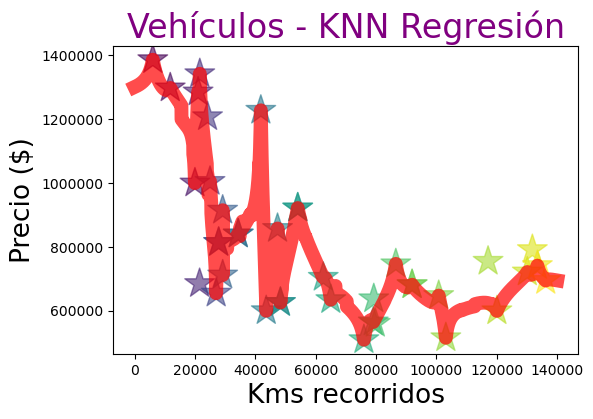

In [27]:
# Múltiples regresiones de los valores dentro del rango
kms_instancias = escala_kms.transform(np.arange(140000).reshape(-1, 1))
precio_instancias = mejor_knn.predict(kms_instancias)
todas = escala_precio.inverse_transform(precio_instancias)
todas = todas.reshape(1, -1)

# Graficar los resultados de las múltiples regresiones
fig = plt.figure(figsize=(6, 4))

plt.plot(np.arange(140000), todas.reshape(1, -1)[0], 
        linewidth=10, color="red", alpha=0.7)

plt.scatter(carros["kms"], carros["precio"], marker="*",
            s=500, c=range(carros["kms"].size), alpha=0.6)

plt.title("Vehículos - KNN Regresión", size=24, color="purple")
plt.ylabel("Precio ($)", size=19)
plt.xlabel("Kms recorridos", size=19)
plt.ticklabel_format(style="plain")
plt.show()